In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
from google.colab import files
import pandas as pd

# Upload your superstore.csv file
uploaded = files.upload()

# Get the uploaded filename automatically
filename = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(filename, encoding="latin1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Saving superstore.csv to superstore.csv
Dataset loaded successfully!
Rows: 9994
Columns: 21


In [5]:
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Column Names:")
for column in df.columns:
    print(column)

Column Names:
Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


In [7]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Remove unnecessary spaces from column names
df.columns = df.columns.str.strip()

print("Data cleaning completed.")

Data cleaning completed.


In [9]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

# Calculate shipping days
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Profit margin
df["Profit Margin"] = (
    df["Profit"] / df["Sales"]
) * 100

display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Year-Month,Shipping Days,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,November,2016-11,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,November,2016-11,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,June,2016-06,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,October,2015-10,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,October,2015-10,7,11.25


In [10]:
print("Rows after cleaning:", df.shape[0])
print("Columns after cleaning:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows after cleaning: 9994
Columns after cleaning: 27

Missing values:
0

Duplicate rows:
0


In [11]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

profit_margin = (total_profit / total_sales) * 100

print("========== BUSINESS KPIs ==========")
print("Total Sales      :", round(total_sales, 2))
print("Total Profit     :", round(total_profit, 2))
print("Total Quantity   :", total_quantity)
print("Total Orders     :", total_orders)
print("Total Customers  :", total_customers)
print("Profit Margin    :", round(profit_margin, 2), "%")

========== BUSINESS KPIs ==========
Total Sales      : 2297200.86
Total Profit     : 286397.02
Total Quantity   : 37873
Total Orders     : 5009
Total Customers  : 793
Profit Margin    : 12.47 %


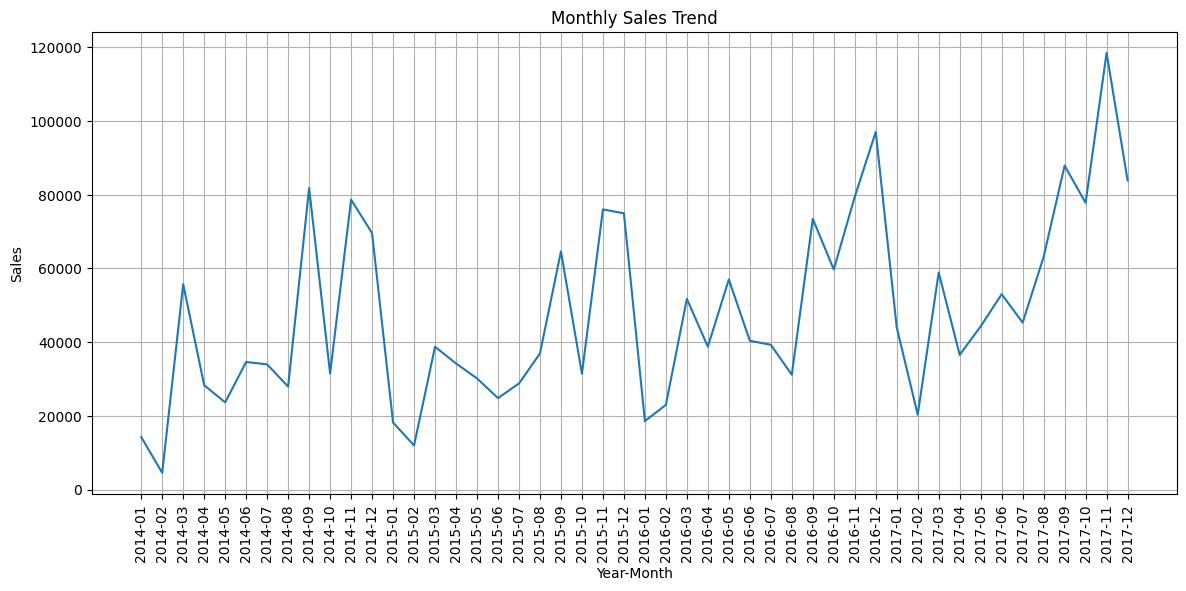

In [12]:
monthly_sales = df.groupby("Year-Month")["Sales"].sum()

plt.figure(figsize=(14,6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)
plt.grid(True)

plt.show()

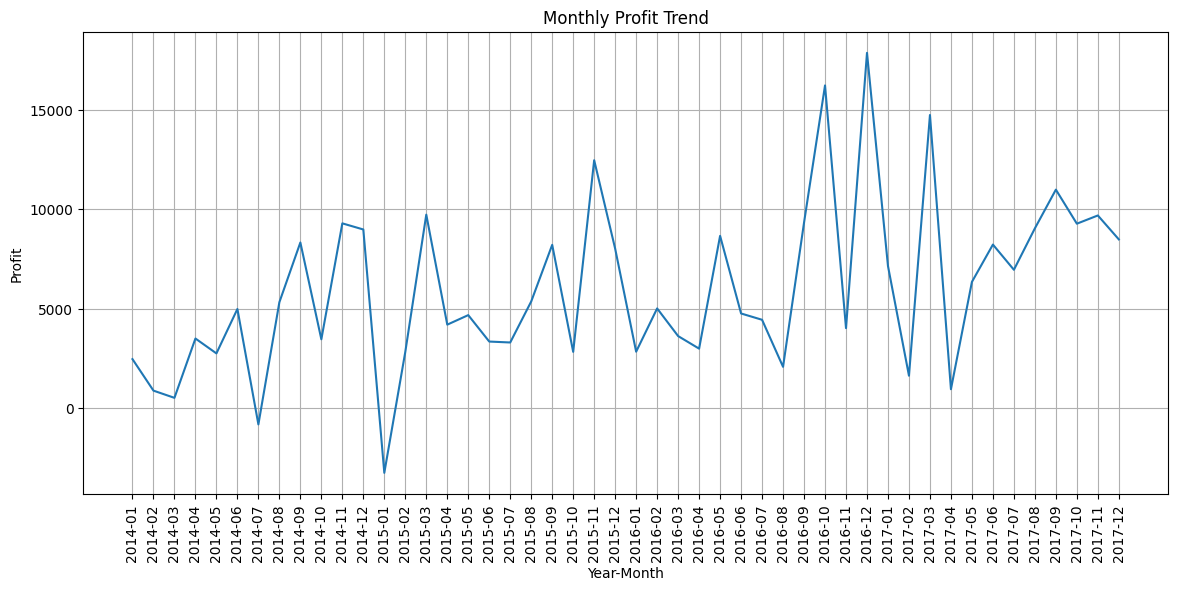

In [14]:
monthly_profit = df.groupby("Year-Month")["Profit"].sum()

plt.figure(figsize=(14,6))

plt.plot(monthly_profit.index, monthly_profit.values)

plt.title("Monthly Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Profit")

plt.xticks(rotation=90)
plt.grid(True)

plt.show()

In [15]:
yearly_sales = df.groupby("Year")["Sales"].sum()

print("Year-wise Sales:")
display(yearly_sales)

Year-wise Sales:


,Sales
Year,
2014,484247.4981
2015,470532.5090
2016,609205.5980
2017,733215.2552


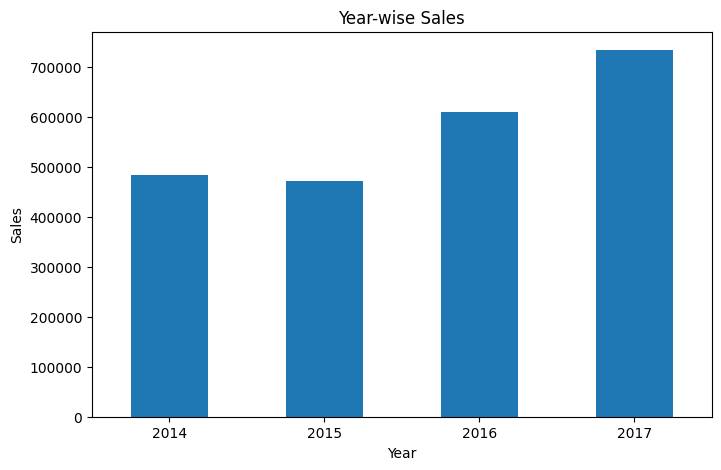

In [16]:
plt.figure(figsize=(8,5))

yearly_sales.plot(kind="bar")

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.show()

In [17]:
yearly_profit = df.groupby("Year")["Profit"].sum()

print("Year-wise Profit:")
display(yearly_profit)

Year-wise Profit:


,Profit
Year,
2014,49543.9741
2015,61618.6037
2016,81795.1743
2017,93439.2696


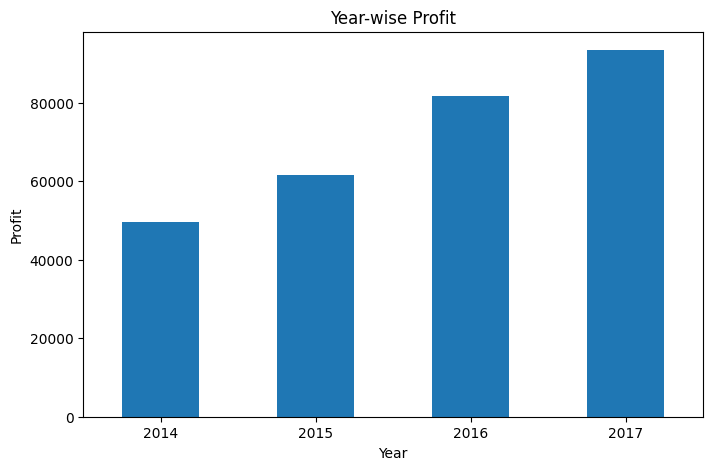

In [18]:
plt.figure(figsize=(8,5))

yearly_profit.plot(kind="bar")

plt.title("Year-wise Profit")
plt.xlabel("Year")
plt.ylabel("Profit")

plt.xticks(rotation=0)
plt.show()

In [19]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Sales:")
display(top_products)

Top 10 Products by Sales:


,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


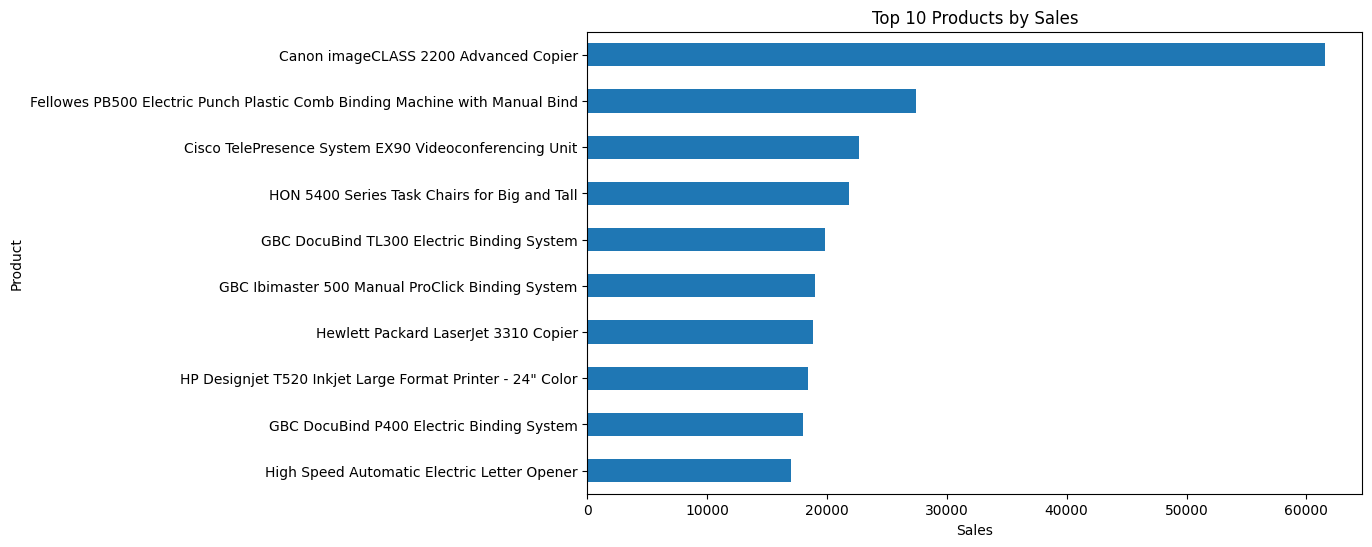

In [20]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

In [21]:
top_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Profit:")
display(top_profit_products)

Top 10 Products by Profit:


,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


In [22]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Category-wise Sales:")
display(category_sales)

Category-wise Sales:


,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [23]:
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Category-wise Profit:")
display(category_profit)

Category-wise Profit:


,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


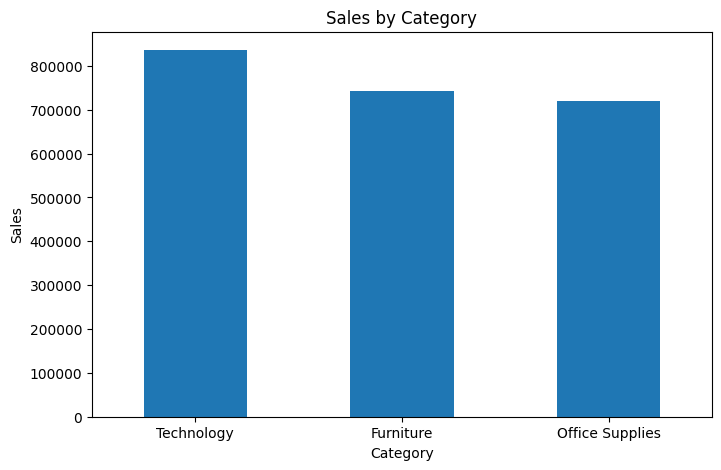

In [24]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.show()

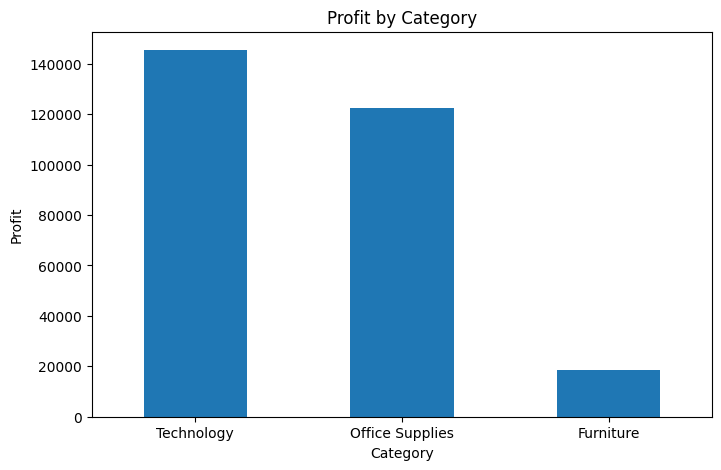

In [25]:
plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)
plt.show()

In [26]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Region-wise Sales:")
display(region_sales)

Region-wise Sales:


,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


In [27]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Region-wise Profit:")
display(region_profit)

Region-wise Profit:


,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


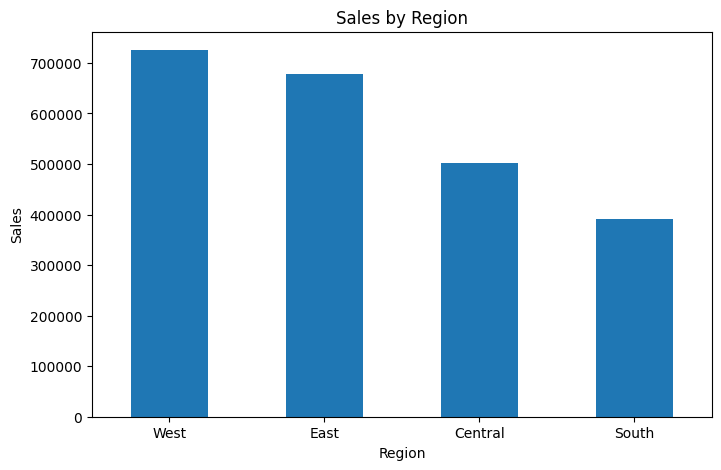

In [28]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.show()

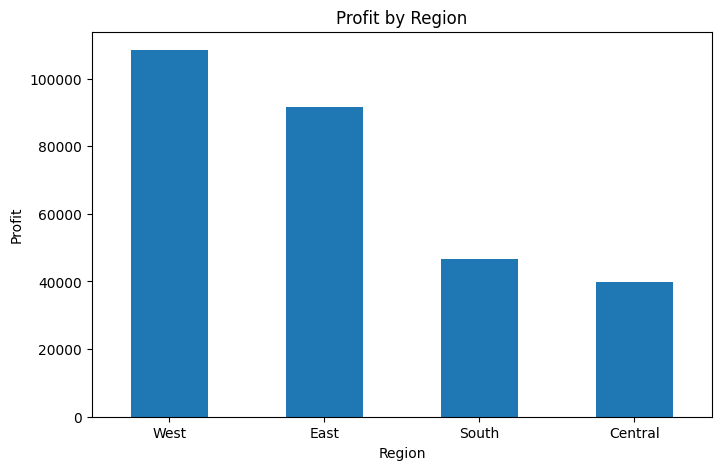

In [29]:
plt.figure(figsize=(8,5))

region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.xticks(rotation=0)
plt.show()

In [30]:
subcategory = (
    df.groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Sales", ascending=False)
)

display(subcategory)

,Sales,Profit,Quantity
Sub-Category,,,
Phones,330007.0540,44515.7306,3289
Chairs,328449.1030,26590.1663,2356
Storage,223843.6080,21278.8264,3158
Tables,206965.5320,-17725.4811,1241
Binders,203412.7330,30221.7633,5974
Machines,189238.6310,3384.7569,440
Accessories,167380.3180,41936.6357,2976
Copiers,149528.0300,55617.8249,234
Bookcases,114879.9963,-3472.5560,868


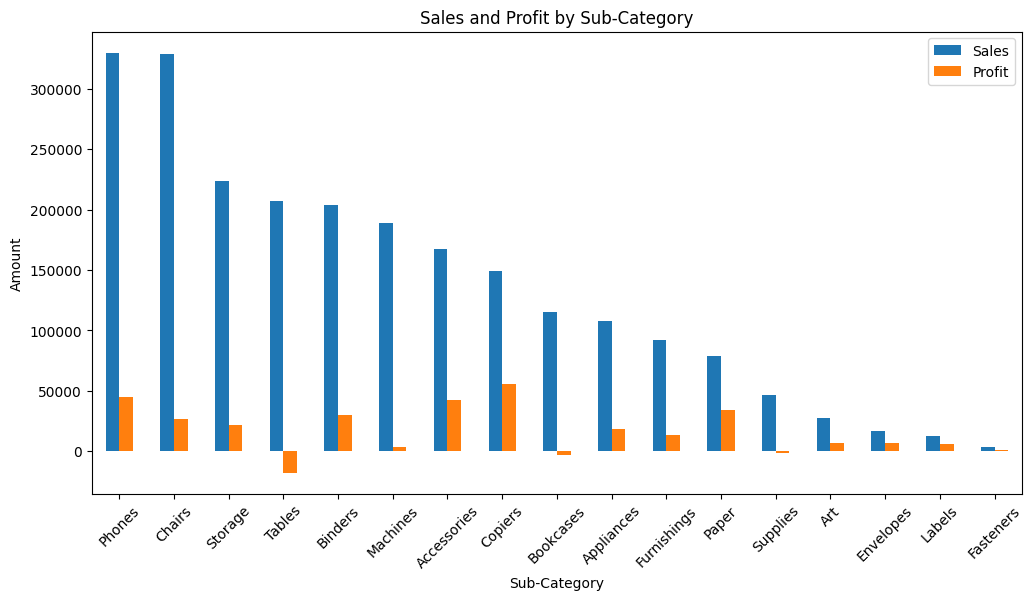

In [31]:
subcategory.plot(
    y=["Sales", "Profit"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Sales and Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Amount")

plt.xticks(rotation=45)
plt.show()

In [32]:
loss_making = (
    subcategory[subcategory["Profit"] < 0]
    .sort_values("Profit")
)

print("Loss-Making Sub-Categories:")
display(loss_making)

Loss-Making Sub-Categories:


,Sales,Profit,Quantity
Sub-Category,,,
Tables,206965.5320,-17725.4811,1241
Bookcases,114879.9963,-3472.5560,868
Supplies,46673.5380,-1189.0995,647


In [33]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Customer Segment:")
display(segment_sales)

Sales by Customer Segment:


,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


In [34]:
segment_profit = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Profit by Customer Segment:")
display(segment_profit)

Profit by Customer Segment:


,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


In [35]:
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 States by Sales:")
display(state_sales)

Top 10 States by Sales:


,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


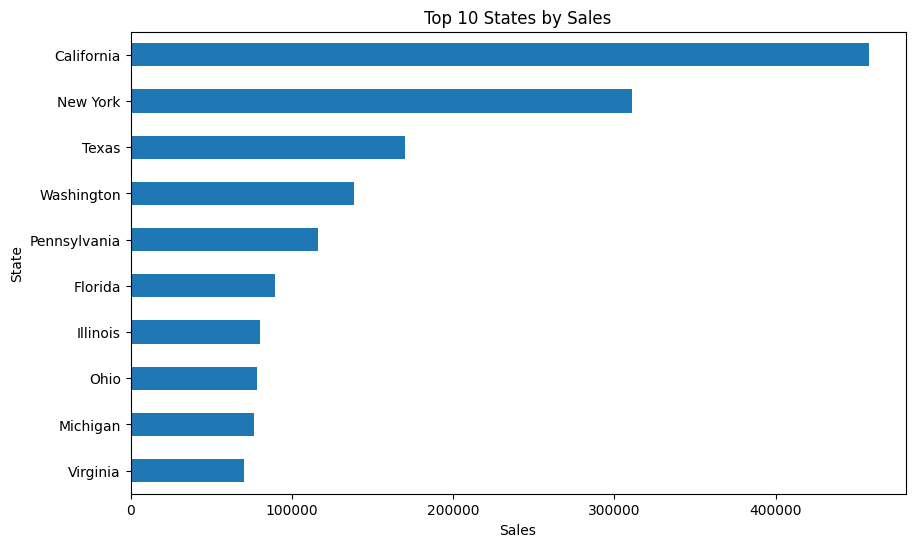

In [36]:
plt.figure(figsize=(10,6))

state_sales.sort_values().plot(kind="barh")

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.show()

In [37]:
state_profit = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 States by Profit:")
display(state_profit)

Top 10 States by Profit:


,Profit
State,
California,76381.3871
New York,74038.5486
Washington,33402.6517
Michigan,24463.1876
Virginia,18597.9504
Indiana,18382.9363
Georgia,16250.0433
Kentucky,11199.6966
Minnesota,10823.1874


In [38]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .sum()
    .sort_index()
)

print("Discount vs Profit:")
display(discount_profit)

Discount vs Profit:


,Profit
Discount,
0.00,320987.6032
0.10,9029.1770
0.15,1418.9915
0.20,90337.3060
0.30,-10369.2774
0.32,-2391.1377
0.40,-23057.0504
0.45,-2493.1111
0.50,-20506.4281


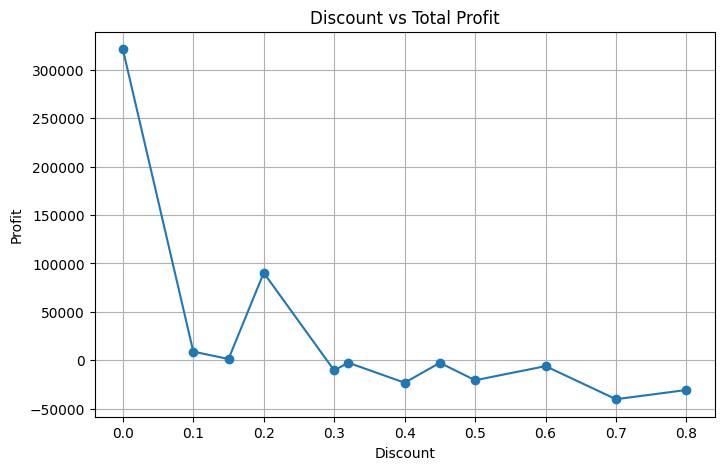

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    discount_profit.index,
    discount_profit.values,
    marker="o"
)

plt.title("Discount vs Total Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(True)
plt.show()

In [40]:
correlation = df[[
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]].corr()

display(correlation)

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


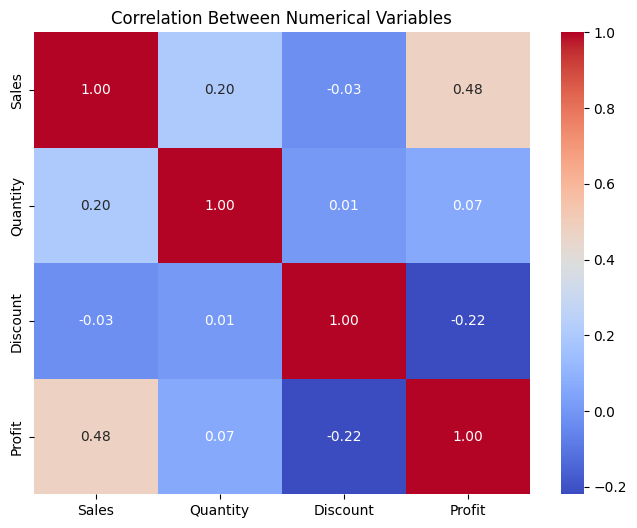

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

In [42]:
correlation = df[[
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]].corr()

display(correlation)

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


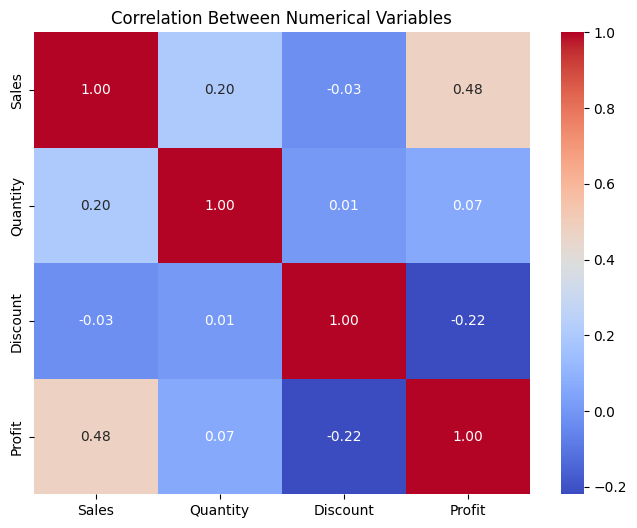

In [43]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

In [44]:
product_analysis = (
    df.groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

product_analysis["Profit Margin"] = (
    product_analysis["Profit"] /
    product_analysis["Sales"]
) * 100

print("Top products by sales:")
display(
    product_analysis
    .sort_values("Sales", ascending=False)
    .head(10)
)

Top products by sales:


,Sales,Profit,Quantity,Profit Margin
Product Name,,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20,4.090909e+01
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31,2.824074e+01
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6,-8.000000e+00
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,39,2.599082e-16
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37,1.126697e+01
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48,4.000000e+00
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38,3.707006e+01
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12,2.228571e+01
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27,-1.045455e+01


In [45]:
print("Top 10 Most Profitable Products:")

display(
    product_analysis
    .sort_values("Profit", ascending=False)
    .head(10)
)

Top 10 Most Profitable Products:


,Sales,Profit,Quantity,Profit Margin
Product Name,,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,40.909091
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,31,28.240741
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,37.070064
Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,39.337349
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,12,22.285714
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11,49.000000
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11,26.000000
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,24,39.459459
Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13,21.071429


In [46]:
monthly_analysis = (
    df.groupby("Year-Month")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

monthly_analysis["Profit Margin"] = (
    monthly_analysis["Profit"] /
    monthly_analysis["Sales"]
) * 100

display(monthly_analysis)

,Sales,Profit,Quantity,Profit Margin
Year-Month,,,,
2014-01,14236.8950,2450.1907,284,17.210148
2014-02,4519.8920,862.3084,159,19.078075
2014-03,55691.0090,498.7299,585,0.895530
2014-04,28295.3450,3488.8352,536,12.330068
2014-05,23648.2870,2738.7096,466,11.581006
2014-06,34595.1276,4976.5244,521,14.385044
2014-07,33946.3930,-841.4826,550,-2.478857
2014-08,27909.4685,5318.1050,609,19.054842
2014-09,81777.3508,8328.0994,1000,10.183870


In [47]:
best_month = monthly_analysis["Sales"].idxmax()
best_month_sales = monthly_analysis.loc[best_month, "Sales"]

print("Best Sales Month:", best_month)
print("Sales:", round(best_month_sales, 2))

Best Sales Month: 2017-11
Sales: 118447.82


In [48]:
best_profit_month = monthly_analysis["Profit"].idxmax()
best_profit = monthly_analysis.loc[best_profit_month, "Profit"]

print("Best Profit Month:", best_profit_month)
print("Profit:", round(best_profit, 2))

Best Profit Month: 2016-12
Profit: 17885.31


In [49]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

best_region = region_sales.idxmax()
best_region_sales = region_sales.max()

print("Best Category:", best_category)
print("Category Sales:", round(best_category_sales, 2))

print("\nBest Region:", best_region)
print("Region Sales:", round(best_region_sales, 2))

Best Category: Technology
Category Sales: 836154.03

Best Region: West
Region Sales: 725457.82


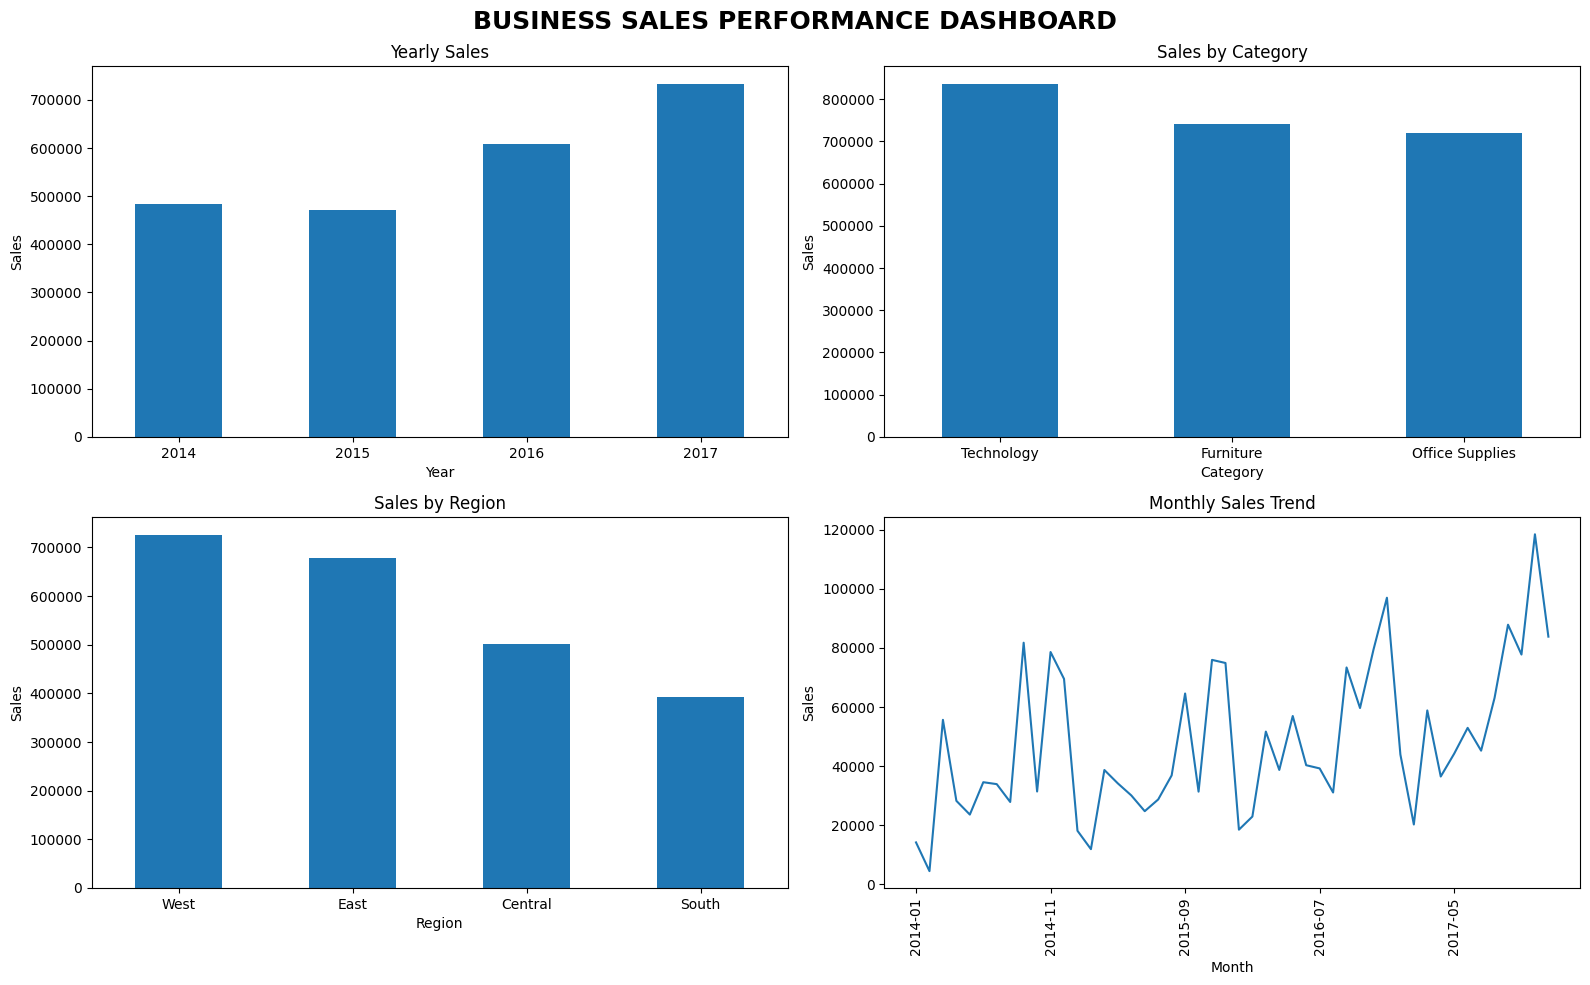

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# Sales by Year
yearly_sales.plot(
    kind="bar",
    ax=axes[0,0]
)
axes[0,0].set_title("Yearly Sales")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Sales")
axes[0,0].tick_params(axis="x", rotation=0)

# Category Sales
category_sales.plot(
    kind="bar",
    ax=axes[0,1]
)
axes[0,1].set_title("Sales by Category")
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Sales")
axes[0,1].tick_params(axis="x", rotation=0)

# Region Sales
region_sales.plot(
    kind="bar",
    ax=axes[1,0]
)
axes[1,0].set_title("Sales by Region")
axes[1,0].set_xlabel("Region")
axes[1,0].set_ylabel("Sales")
axes[1,0].tick_params(axis="x", rotation=0)

# Monthly Sales
monthly_sales.plot(
    ax=axes[1,1]
)
axes[1,1].set_title("Monthly Sales Trend")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Sales")
axes[1,1].tick_params(axis="x", rotation=90)

plt.suptitle(
    "BUSINESS SALES PERFORMANCE DASHBOARD",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [51]:
kpi = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Total Quantity",
        "Profit Margin"
    ],
    "Value": [
        round(total_sales, 2),
        round(total_profit, 2),
        total_orders,
        total_customers,
        total_quantity,
        round(profit_margin, 2)
    ]
})

display(kpi)

,KPI,Value
0,Total Sales,2297200.86
1,Total Profit,286397.02
2,Total Orders,5009.00
3,Total Customers,793.00
4,Total Quantity,37873.00
5,Profit Margin,12.47


In [52]:
print("========== BUSINESS INSIGHTS ==========\n")

print(
    f"1. Total sales generated by the business are "
    f"{total_sales:,.2f}."
)

print(
    f"2. Total profit generated is "
    f"{total_profit:,.2f}, with an overall profit margin "
    f"of {profit_margin:.2f}%."
)

print(
    f"3. {best_category} is the highest-selling category."
)

print(
    f"4. {best_region} is the highest-selling region."
)

print(
    f"5. {best_month} recorded the highest monthly sales."
)

print(
    f"6. {best_profit_month} recorded the highest monthly profit."
)

print(
    f"7. The best-selling product is "
    f"{top_products.index[0]}."
)

========== BUSINESS INSIGHTS ==========

1. Total sales generated by the business are 2,297,200.86.
2. Total profit generated is 286,397.02, with an overall profit margin of 12.47%.
3. Technology is the highest-selling category.
4. West is the highest-selling region.
5. 2017-11 recorded the highest monthly sales.
6. 2016-12 recorded the highest monthly profit.
7. The best-selling product is Canon imageCLASS 2200 Advanced Copier.


In [53]:
print("========== AREAS REQUIRING ATTENTION ==========\n")

print("Loss-making sub-categories:")

for subcategory_name, row in loss_making.iterrows():
    print(
        f"- {subcategory_name}: "
        f"Profit = {row['Profit']:,.2f}"
    )

========== AREAS REQUIRING ATTENTION ==========

Loss-making sub-categories:
- Tables: Profit = -17,725.48
- Bookcases: Profit = -3,472.56
- Supplies: Profit = -1,189.10


In [54]:
print("========== BUSINESS RECOMMENDATIONS ==========\n")

print("1. Focus marketing and inventory planning on the highest-selling products.")

print("2. Strengthen sales strategies in the highest-performing region.")

print("3. Investigate loss-making sub-categories such as Tables and Bookcases.")

print("4. Review discount strategies because excessive discounts can reduce profitability.")

print("5. Promote high-profit products to improve overall profit margins.")

print("6. Study monthly sales trends and prepare inventory before high-demand periods.")

print("7. Focus on profitable customer segments and regions for future growth.")

========== BUSINESS RECOMMENDATIONS ==========

1. Focus marketing and inventory planning on the highest-selling products.
2. Strengthen sales strategies in the highest-performing region.
3. Investigate loss-making sub-categories such as Tables and Bookcases.
4. Review discount strategies because excessive discounts can reduce profitability.
5. Promote high-profit products to improve overall profit margins.
6. Study monthly sales trends and prepare inventory before high-demand periods.
7. Focus on profitable customer segments and regions for future growth.


In [55]:
df.to_csv(
    "cleaned_superstore.csv",
    index=False
)

print("Cleaned dataset saved as cleaned_superstore.csv")

Cleaned dataset saved as cleaned_superstore.csv


In [56]:
category_sales.to_csv("category_sales.csv")
region_sales.to_csv("region_sales.csv")
top_products.to_csv("top_products.csv")
monthly_analysis.to_csv("monthly_sales_profit.csv")
subcategory.to_csv("subcategory_analysis.csv")

print("Analysis files saved successfully.")

Analysis files saved successfully.


In [57]:
print("=" * 60)
print("       BUSINESS SALES PERFORMANCE ANALYTICS")
print("=" * 60)

print("\n1. DATASET")
print("-" * 60)
print("Number of records:", len(df))
print("Number of columns:", len(df.columns))
print("Analysis period:",
      df["Order Date"].min().date(),
      "to",
      df["Order Date"].max().date())

print("\n2. KEY PERFORMANCE INDICATORS")
print("-" * 60)
print(f"Total Sales       : {total_sales:,.2f}")
print(f"Total Profit      : {total_profit:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Profit Margin     : {profit_margin:.2f}%")

print("\n3. TOP CATEGORY")
print("-" * 60)
print(best_category)
print(f"Sales: {best_category_sales:,.2f}")

print("\n4. TOP REGION")
print("-" * 60)
print(best_region)
print(f"Sales: {best_region_sales:,.2f}")

print("\n5. TOP PRODUCT")
print("-" * 60)
print(top_products.index[0])
print(f"Sales: {top_products.iloc[0]:,.2f}")

print("\n6. BEST SALES MONTH")
print("-" * 60)
print(best_month)
print(f"Sales: {best_month_sales:,.2f}")

print("\n7. BEST PROFIT MONTH")
print("-" * 60)
print(best_profit_month)
print(f"Profit: {best_profit:,.2f}")

print("\n8. RECOMMENDATIONS")
print("-" * 60)
print("• Focus on high-performing products and categories.")
print("• Expand successful regional sales strategies.")
print("• Review loss-making sub-categories.")
print("• Control excessive discounts.")
print("• Use monthly trends for inventory planning.")

print("\n" + "=" * 60)
print("                 END OF ANALYSIS")
print("=" * 60)

       BUSINESS SALES PERFORMANCE ANALYTICS

1. DATASET
------------------------------------------------------------
Number of records: 9994
Number of columns: 27
Analysis period: 2014-01-03 to 2017-12-30

2. KEY PERFORMANCE INDICATORS
------------------------------------------------------------
Total Sales       : 2,297,200.86
Total Profit      : 286,397.02
Total Orders      : 5,009
Total Customers   : 793
Total Quantity    : 37,873
Profit Margin     : 12.47%

3. TOP CATEGORY
------------------------------------------------------------
Technology
Sales: 836,154.03

4. TOP REGION
------------------------------------------------------------
West
Sales: 725,457.82

5. TOP PRODUCT
------------------------------------------------------------
Canon imageCLASS 2200 Advanced Copier
Sales: 61,599.82

6. BEST SALES MONTH
------------------------------------------------------------
2017-11
Sales: 118,447.82

7. BEST PROFIT MONTH
------------------------------------------------------------
2016-1